# Dirichlet-Sampled Class Weights — Searching the Weight Simplex

With two classes, sweeping the class weight is easy: one number from 0 to 1 and the other is its
complement. With **three or more** classes it is no longer a line but a *simplex* — a triangle of
valid weight combinations — and a grid over it is both wasteful and awkward to write.

The fix is to sample the simplex at random, which is exactly what the **Dirichlet distribution**
does: every draw is a vector of positive numbers summing to 1. Feed those draws to `GridSearchCV` as
candidate weights and the search becomes a random search over the whole space.

## Learning objectives

- Explain why weight tuning becomes a simplex search beyond two classes
- Draw valid weight vectors from a Dirichlet distribution
- Pass sampled weights to `GridSearchCV` as a candidate list
- Score multiclass models with macro $F_1$ and stratified folds

## Background

This notebook assumes class weighting from `U1-7_Imbalance-4_ClassWeights`, `GridSearchCV` from
`U1-3_Regression-4_GridSearchCV`, and `StratifiedKFold` from `U1-7_Imbalance-1_StratifiedKFold`. The
Dirichlet distribution is introduced in section 3 where it is first sampled.

**Prerequisites:** `U1-7_Imbalance-4_ClassWeights` (class weights),
`U1-3_Regression-4_GridSearchCV` (grid search), `U1-7_Imbalance-1_StratifiedKFold`

**Dataset:** none — three 2-D Gaussian blobs at 800 / 400 / 200 samples, a 4:2:1 imbalance.

**References:** https://en.wikipedia.org/wiki/Dirichlet_distribution

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Tools: entropy, region painting, and the data generator

Three helpers carried across the imbalance notebooks.

`GenerateData(n_pts0, n_pts1, center_sep, std)` draws two 2-D Gaussian clouds with a controllable
**imbalance ratio** — the two counts are independent, so a 10:1 or 4:1 split is one argument away —
and a controllable **overlap** via `center_sep` and `std`. Imbalance and overlap are separate
problems and this lets us vary them separately.

`entropy` and `visualize_regions` are the decision-region tools from
`U1-6_Classify-1_CompareRegions`: predict on a dense grid, reshape into an image, and return both
the predicted class and the entropy of the predicted probabilities at each point.

In [2]:
import math

def entropy( x, b ):
    s = 0
    for p in x:
        if p > 0:
            s += -p*math.log(p,b)
        # end
    # end
    return s
# end

def visualize_regions(model, MAX, nGrid):
    a1 = np.linspace(-MAX, MAX, nGrid)
    a2 = np.linspace(-MAX, MAX, nGrid)

    A1, A2 = np.meshgrid(a1, a2)
    A1 = A1.flatten()
    A2 = A2.flatten()
    A = np.vstack((A1, A2)).T

    # Predict B
    B = model.predict(A)
    B = B.reshape(nGrid, nGrid)
    B = np.flipud(B)

    # Compute entropy for S
    prob_2D = model.predict_proba(A)
    S = np.array([entropy(p, 2) for p in prob_2D])
    S = S.reshape(nGrid, nGrid)
    S = np.flipud(S)

    return B, S
# end
    
def GenerateData(n_pts1,n_pts2,center_sep,std):
    
    cov = std**2*np.eye(2)
    
    x1 = np.random.multivariate_normal(mean=[-center_sep/2,0],
                                       cov=cov,
                                       size=n_pts1)
    y1 = np.zeros(n_pts1)
    
    x2 = np.random.multivariate_normal(mean=[center_sep/2,0],
                                       cov=cov,
                                       size=n_pts2)
    y2 = np.ones(n_pts2)
    
    X = np.concatenate((x1,x2),axis=0)
    y = np.concatenate((y1,y2),axis=0).astype(int)
    
    return X, y
# end

## 2. Create the data

Three classes at 800 / 400 / 200 — a 4:2:1 imbalance — with explicit centres so two of the blobs sit
closer together than the third. Note `rng` is drawn and printed but the generator is left unseeded,
so each run gives a fresh sample; printing it means a run can be reproduced afterwards if something
interesting appears.

59286850


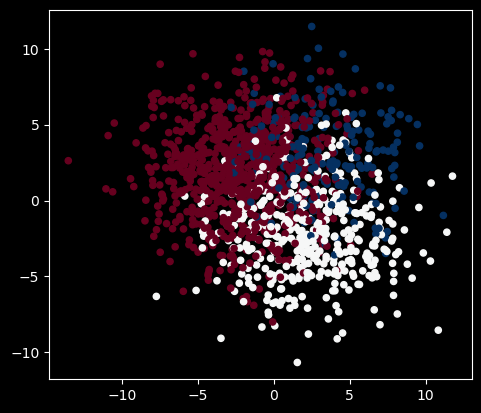

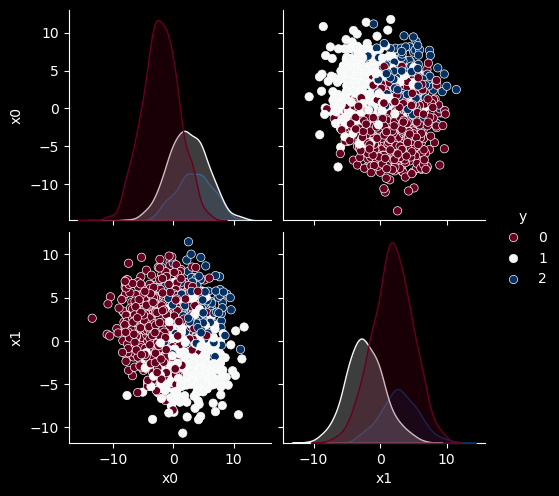

In [3]:
from sklearn.datasets import make_blobs

rng = np.random.randint(0,100000000,1)[0]
print(rng)

# Define the number of samples per class
n_samples_per_class = [800, 400, 200]  # Unequal number of samples per class
centers = [[-2, 2], [2, -2], [3, 3]]  # Define explicit cluster centers

# Generate blobs with specified sample sizes
X, y = make_blobs(
    n_samples=n_samples_per_class,  # Different sample sizes per class
    centers=centers,  # Explicit center coordinates
    n_features=2,  # 2D data
    cluster_std=[3, 3, 3],  # Different spread for each class
    random_state=88028025
)

MAX = np.max(np.abs(X))

cmap = 'RdBu'

plt_scale = 3
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap=cmap)
#plt.xlim(-plt_scale,plt_scale)
#plt.ylim(-plt_scale,plt_scale)
plt.gca().set_aspect('equal')
plt.show()

df = pd.DataFrame( {"x0":X[:,0], "x1":X[:,1], "y":y} )
sns.pairplot(df, hue='y', palette='RdBu')
plt.show()

## 3. Random weights, tried directly

### 3.1 Train/test split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
)

print("Original data:")
print(pd.Series(y).value_counts())
print()
print("Training data:")
print(pd.Series(y_train).value_counts())
print()
print("Testing data:")
print(pd.Series(y_test).value_counts())

Original data:
0    800
1    400
2    200
Name: count, dtype: int64

Training data:
0    640
1    320
2    160
Name: count, dtype: int64

Testing data:
0    160
1     80
2     40
Name: count, dtype: int64


### 3.2 A first look — ten random weight vectors

Before automating anything, draw ten weight vectors at random and look at what each does to the
classification report. The spread across draws is the motivation for searching properly: the
weights matter, and the good ones are not obvious.

{0: np.float64(0.8134486842572909), 1: np.float64(0.11705493372057078), 2: np.float64(0.0694963820221385)}
              precision    recall  f1-score   support

           0       0.66      0.99      0.79       160
           1       0.94      0.41      0.57        80
           2       1.00      0.15      0.26        40

    accuracy                           0.70       280
   macro avg       0.87      0.52      0.54       280
weighted avg       0.79      0.70      0.65       280



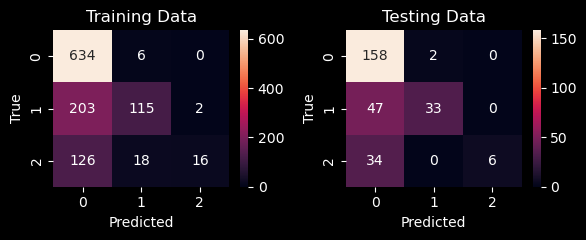

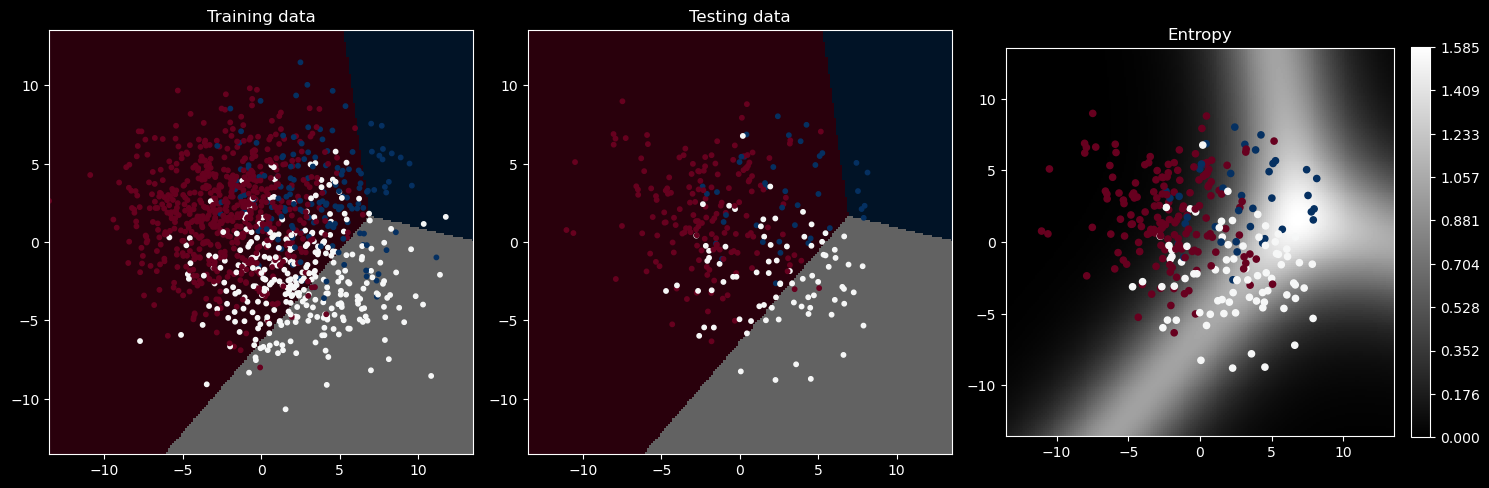

{0: np.float64(0.06226197608858481), 1: np.float64(0.4375096729601334), 2: np.float64(0.5002283509512818)}
              precision    recall  f1-score   support

           0       0.92      0.54      0.68       160
           1       0.55      0.88      0.67        80
           2       0.42      0.62      0.51        40

    accuracy                           0.65       280
   macro avg       0.63      0.68      0.62       280
weighted avg       0.75      0.65      0.65       280



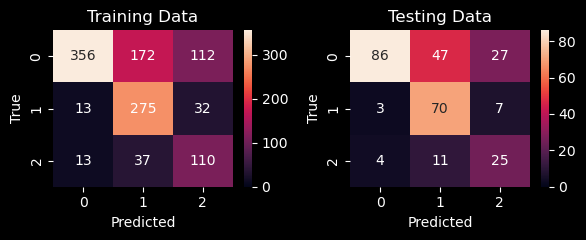

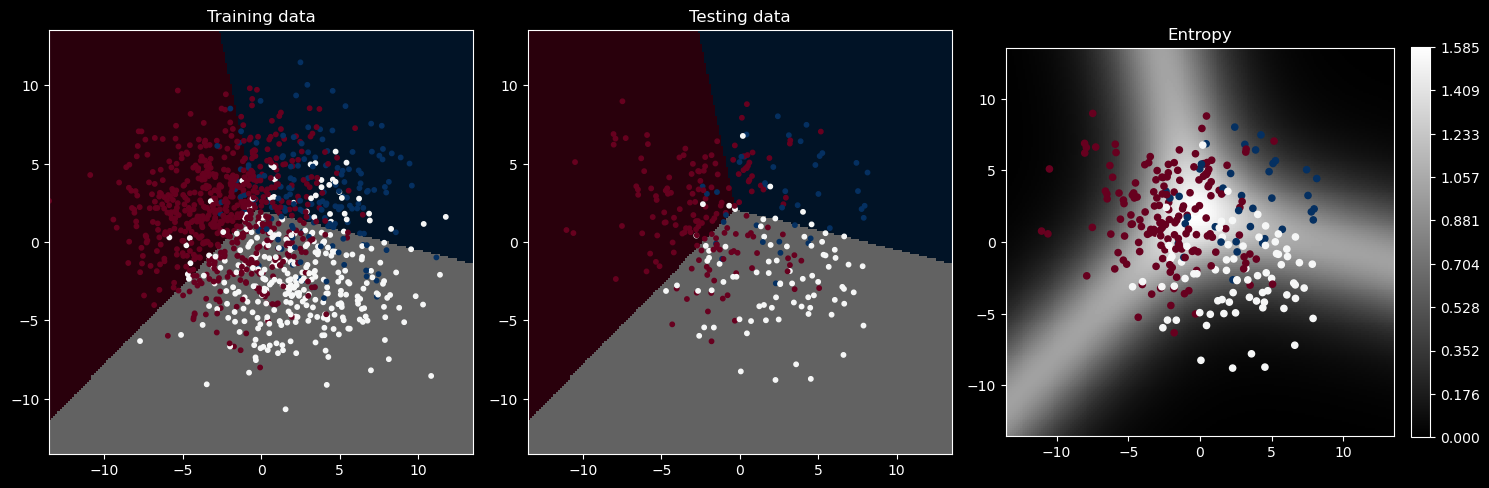

{0: np.float64(0.1681465666486182), 1: np.float64(0.48496683794558754), 2: np.float64(0.34688659540579436)}
              precision    recall  f1-score   support

           0       0.85      0.77      0.81       160
           1       0.62      0.82      0.71        80
           2       0.71      0.50      0.59        40

    accuracy                           0.75       280
   macro avg       0.73      0.70      0.70       280
weighted avg       0.76      0.75      0.75       280



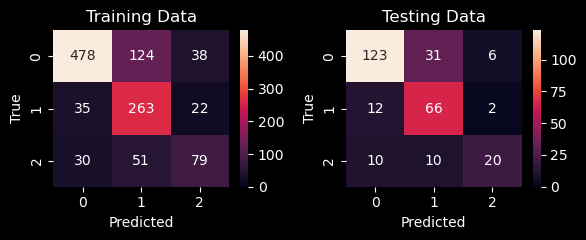

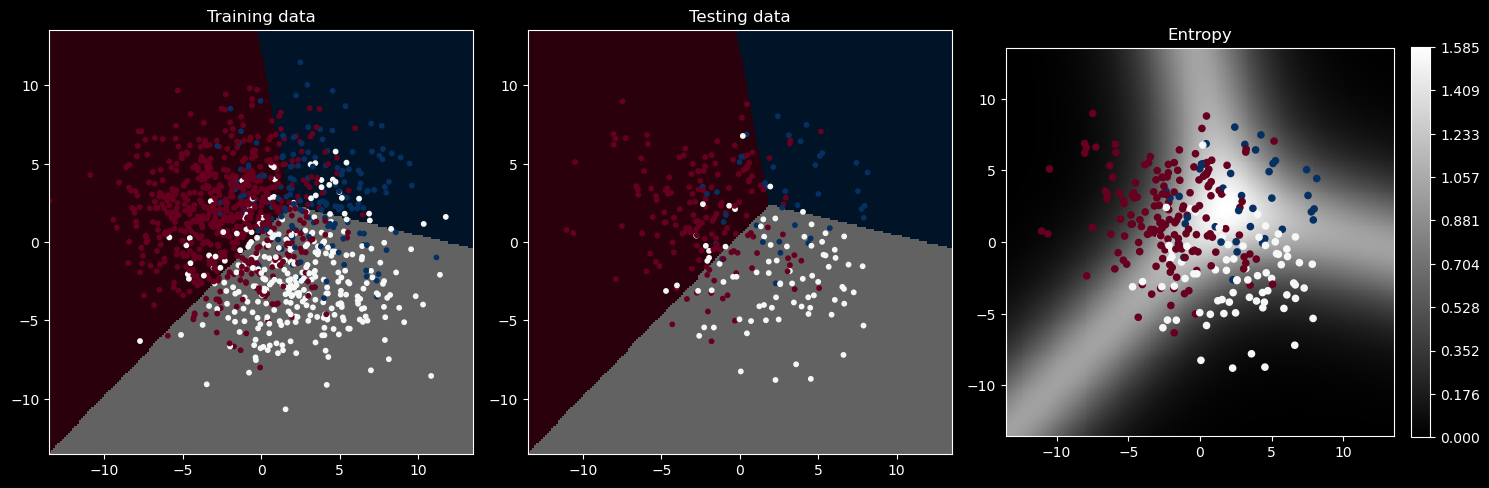

{0: np.float64(0.5024153802126945), 1: np.float64(0.319115848337933), 2: np.float64(0.17846877144937243)}
              precision    recall  f1-score   support

           0       0.75      0.94      0.84       160
           1       0.80      0.69      0.74        80
           2       0.92      0.28      0.42        40

    accuracy                           0.77       280
   macro avg       0.82      0.63      0.67       280
weighted avg       0.79      0.77      0.75       280



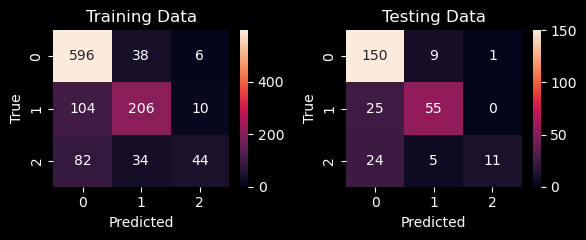

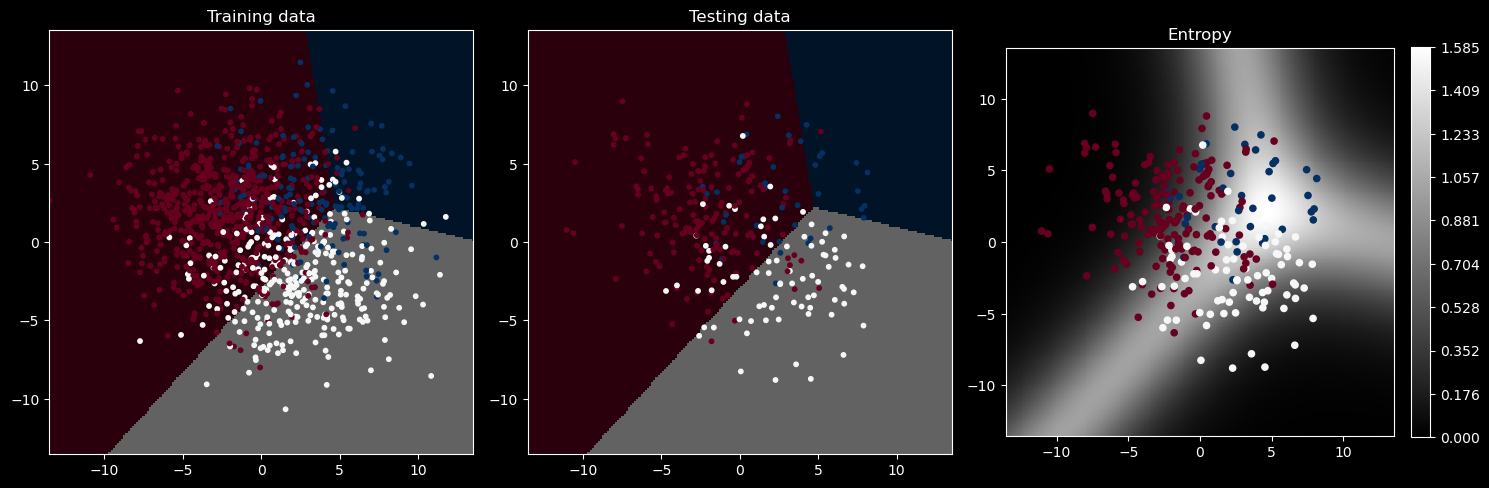

{0: np.float64(0.2789325876247675), 1: np.float64(0.20477312538379264), 2: np.float64(0.5162942869914399)}
              precision    recall  f1-score   support

           0       0.79      0.89      0.84       160
           1       0.80      0.60      0.69        80
           2       0.57      0.57      0.57        40

    accuracy                           0.76       280
   macro avg       0.72      0.69      0.70       280
weighted avg       0.76      0.76      0.76       280



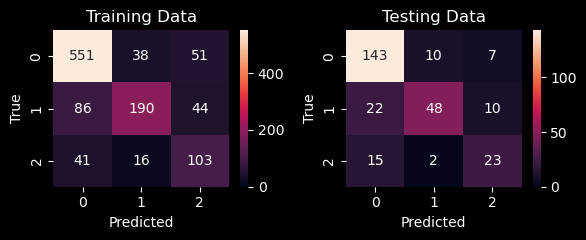

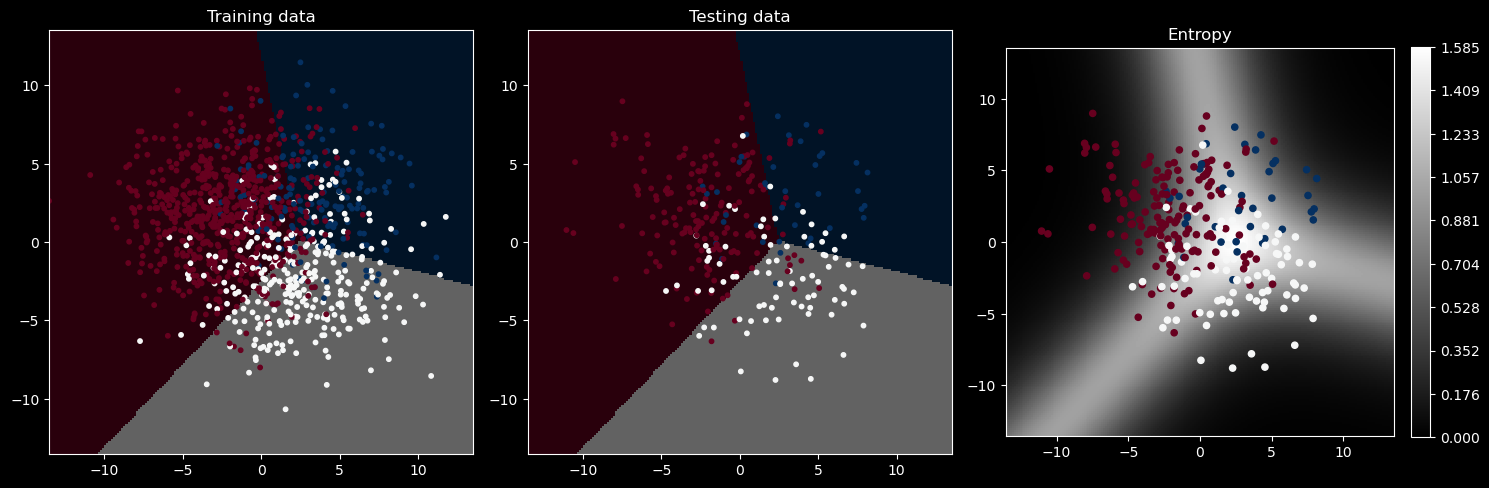

{0: np.float64(0.16357542234763064), 1: np.float64(0.3440799024706043), 2: np.float64(0.4923446751817651)}
              precision    recall  f1-score   support

           0       0.84      0.79      0.81       160
           1       0.67      0.75      0.71        80
           2       0.56      0.57      0.57        40

    accuracy                           0.75       280
   macro avg       0.69      0.70      0.70       280
weighted avg       0.75      0.75      0.75       280



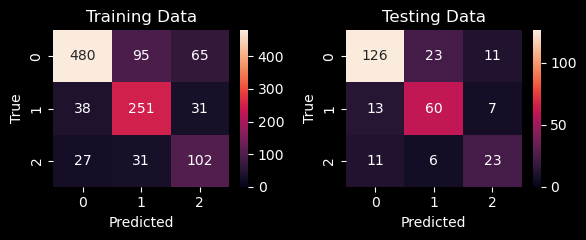

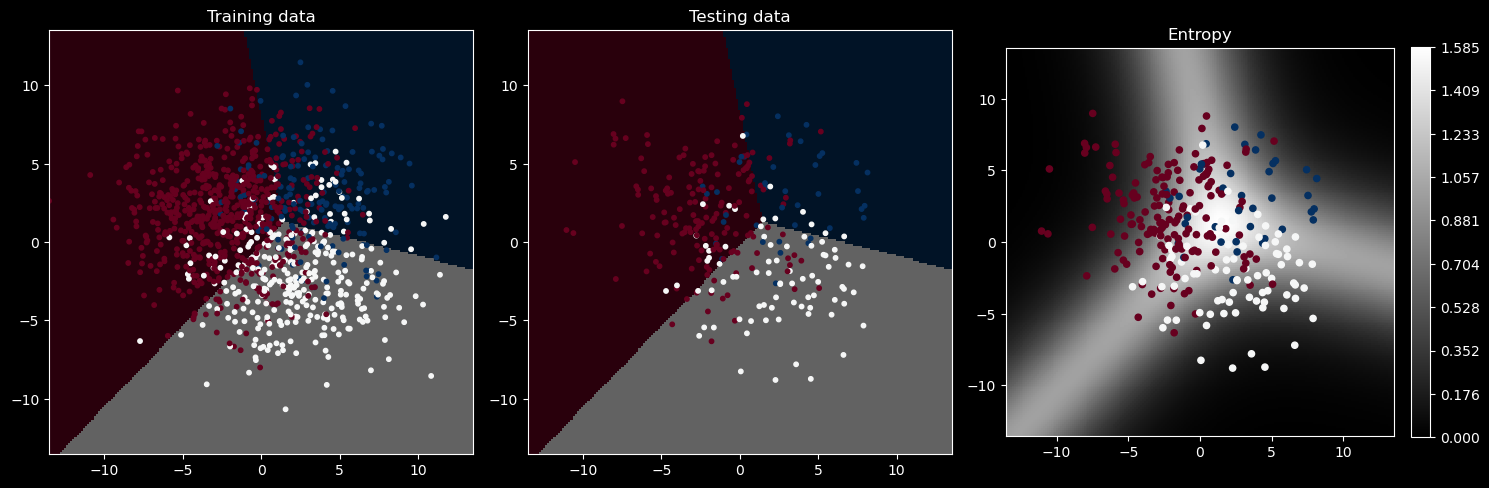

{0: np.float64(0.3352169392699861), 1: np.float64(0.5482219477018416), 2: np.float64(0.11656111302817217)}
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       160
           1       0.66      0.79      0.72        80
           2       0.86      0.15      0.26        40

    accuracy                           0.75       280
   macro avg       0.77      0.61      0.60       280
weighted avg       0.76      0.75      0.72       280



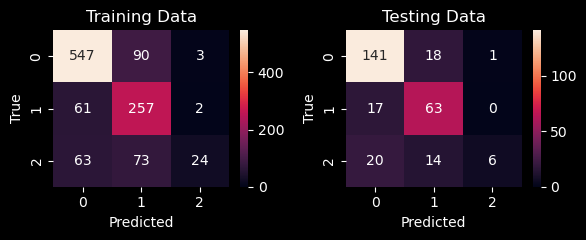

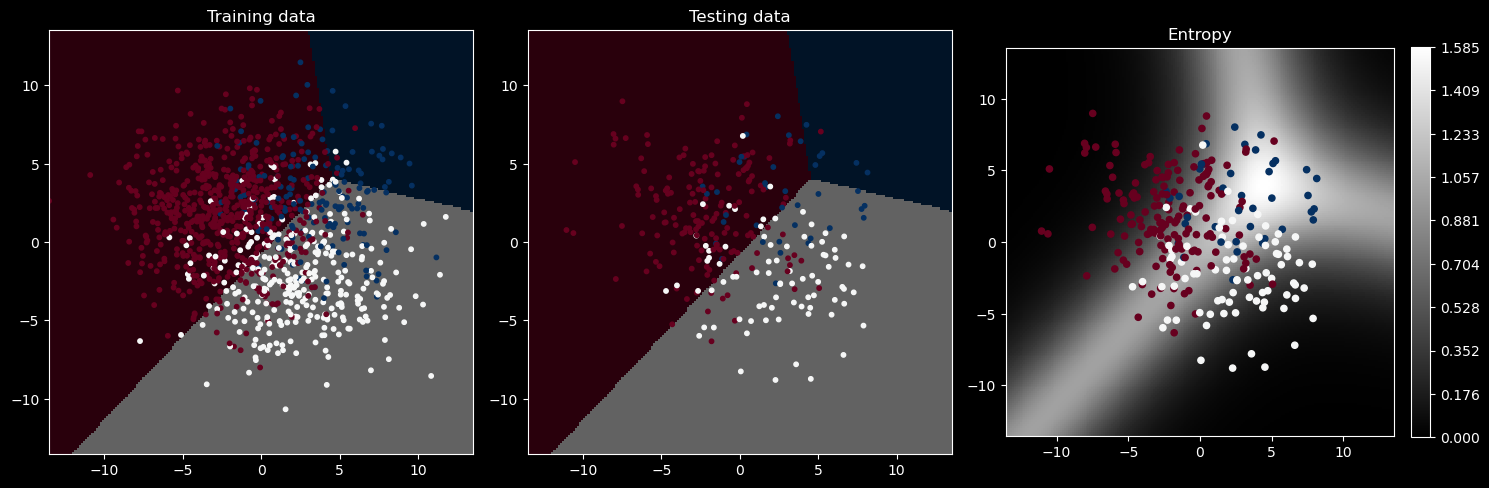

{0: np.float64(0.2954205637682528), 1: np.float64(0.1269892876152443), 2: np.float64(0.5775901486165029)}
              precision    recall  f1-score   support

           0       0.78      0.90      0.83       160
           1       0.83      0.44      0.57        80
           2       0.49      0.65      0.56        40

    accuracy                           0.73       280
   macro avg       0.70      0.66      0.66       280
weighted avg       0.75      0.73      0.72       280



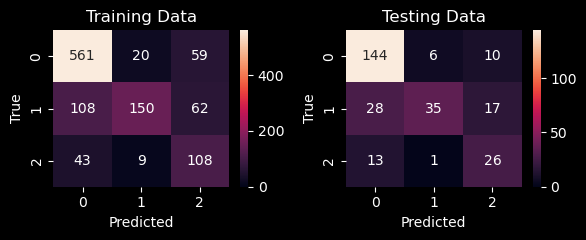

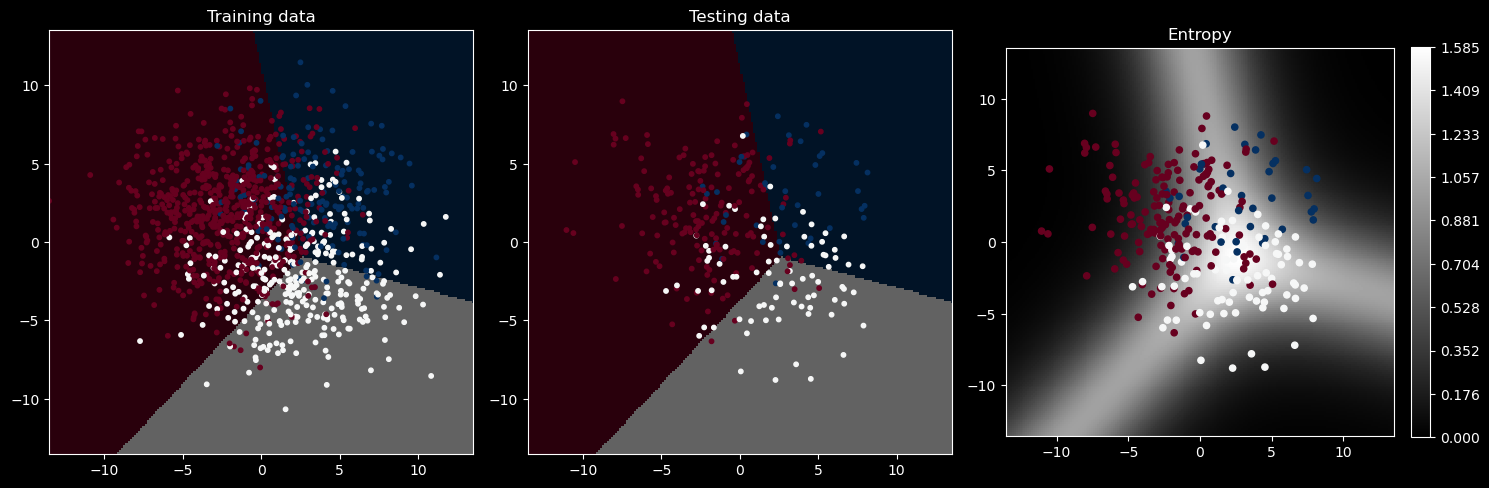

{0: np.float64(0.6609290193144833), 1: np.float64(0.04225145921224394), 2: np.float64(0.2968195214732728)}
              precision    recall  f1-score   support

           0       0.67      0.99      0.80       160
           1       0.95      0.23      0.36        80
           2       0.52      0.33      0.40        40

    accuracy                           0.68       280
   macro avg       0.71      0.51      0.52       280
weighted avg       0.73      0.68      0.62       280



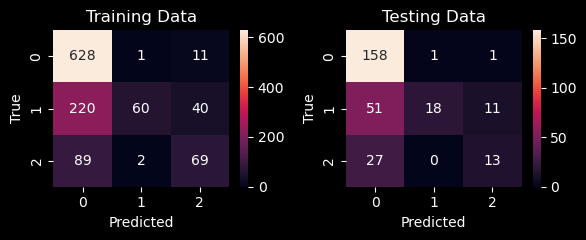

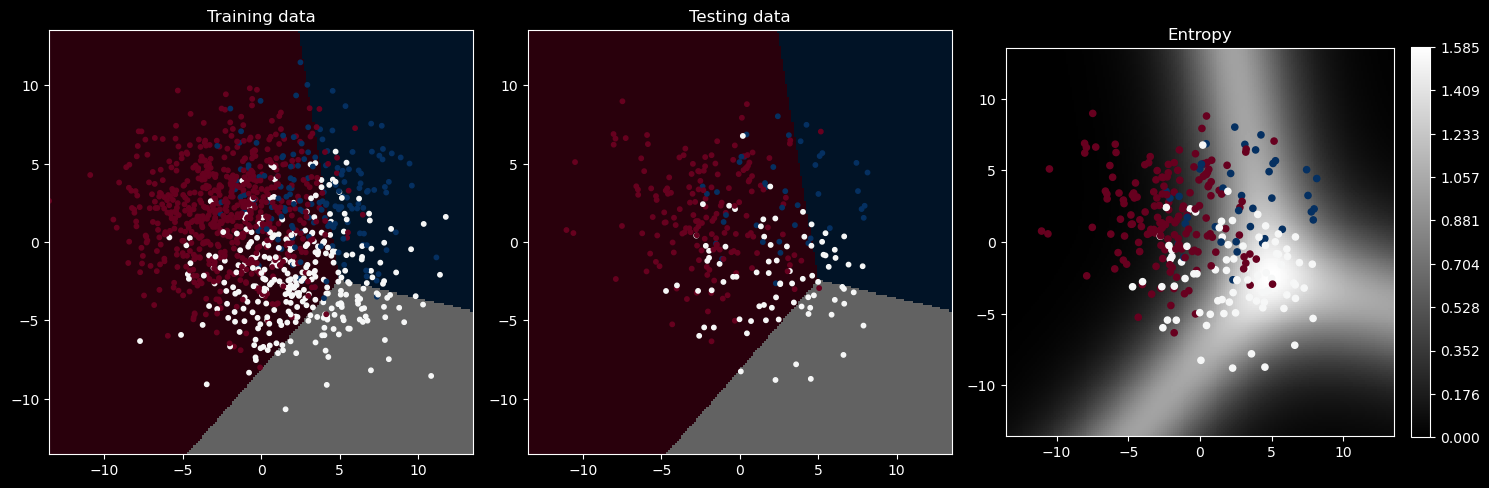

{0: np.float64(0.16486762874584332), 1: np.float64(0.7434969651933532), 2: np.float64(0.09163540606080353)}
              precision    recall  f1-score   support

           0       0.83      0.73      0.78       160
           1       0.54      0.89      0.67        80
           2       0.86      0.15      0.26        40

    accuracy                           0.69       280
   macro avg       0.74      0.59      0.57       280
weighted avg       0.75      0.69      0.67       280



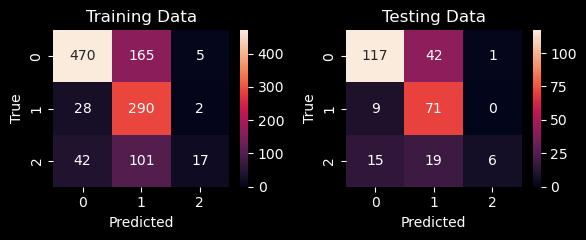

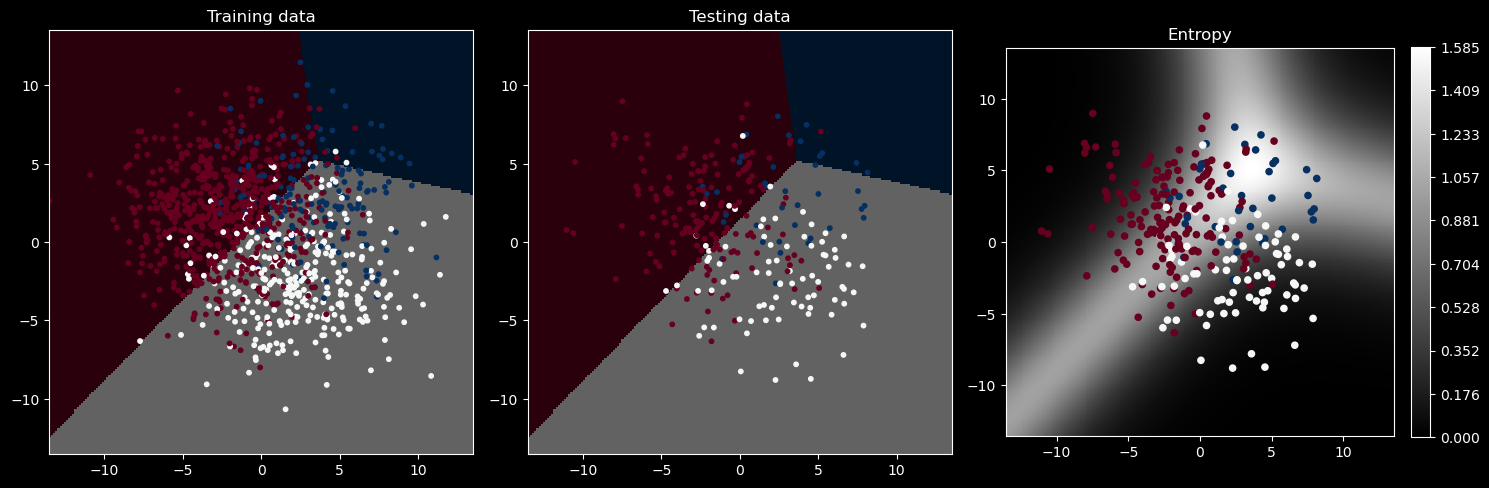

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, classification_report

n_weights = 10

for i in range(n_weights):
    class_weight = np.random.dirichlet(np.ones(3))
    class_weight = {i: class_weight[i] for i in range(len(class_weight))}
    print(class_weight)
    
    model = LogisticRegression(class_weight=class_weight)
    
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train).astype(int)
    y_test_pred = model.predict(X_test).astype(int)
    
    print(classification_report(y_test, y_test_pred))
    
    conf_matrix_train = confusion_matrix(y_train, y_train_pred).astype(int)
    conf_matrix_test = confusion_matrix(y_test, y_test_pred).astype(int)
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2.5))
    
    sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='d', ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")
    
    sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='d', ax=axes[1])
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")
    
    plt.tight_layout()
    plt.show()
    
    B, S = visualize_regions(model, MAX, 200)
    
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,5))
    
    extent = [-MAX,MAX,-MAX,MAX]
    
    cmap = "RdBu"
    axes[0].imshow(B, interpolation='none', extent=extent,cmap=cmap, alpha=0.4)
    axes[0].scatter(X_train[:,0], X_train[:,1], c=y_train, s=10, cmap=cmap);
    axes[0].set_aspect('equal')
    axes[0].set_title('Training data');
    
    axes[1].imshow(B, interpolation='none', extent=extent,cmap=cmap, alpha=0.4)
    axes[1].scatter(X_test[:,0], X_test[:,1], c=y_test, s=10, cmap=cmap);
    axes[1].set_aspect('equal')
    axes[1].set_title('Testing data');
    
    im = axes[2].imshow(S, interpolation='none', extent=extent,cmap='gray')
    axes[2].scatter(X_test[:,0], X_test[:,1], c=y_test, s=20, cmap=cmap);
    axes[2].set_aspect('equal')
    axes[2].set_title('Entropy')
    cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    cbar.set_ticks(np.linspace(0, math.log(y.max()+1,2), 10))
    
    plt.tight_layout()
    plt.show()
# end

### 3.3 Why Dirichlet?

A valid set of class weights is a vector of **positive** numbers that sums to 1 — a point on the
probability simplex. Sampling one uniformly is not as simple as drawing three independent uniforms,
because those will not sum to 1, and rescaling them does not give a uniform distribution over the
simplex.

The **Dirichlet distribution** is the distribution over exactly that space. A draw from
$\text{Dir}(\alpha_1, \ldots, \alpha_K)$ is a vector $(p_1, \ldots, p_K)$ with every $p_k > 0$ and
$\sum_k p_k = 1$. With every $\alpha_k = 1$ — the setting used here — it is *uniform* over the
simplex, so each draw is an unbiased sample of the whole space of valid weight vectors.

The concentration parameters bend that: $\alpha_k < 1$ pushes draws toward the corners (one class
dominant), $\alpha_k > 1$ pulls them toward the centre (near-equal weights). Worth trying, since
"one class dominant" is often where the useful weights live on an imbalanced problem.

Run the cell below and check the rows: all positive, each summing to 1.

#### The Dirichlet distribution itself

A dirichlet distribution is a distribution that can generate a probability distribution over n outcomes, i.e., each of the n values generated in each sample are all greater than 0 and all sum to 1.

https://en.wikipedia.org/wiki/Dirichlet_distribution

In [6]:
np.random.dirichlet(alpha=np.ones(3), size=5)#.sum(axis=1)

array([[0.60759908, 0.14275092, 0.24965   ],
       [0.07132957, 0.68539129, 0.24327914],
       [0.03106187, 0.4407308 , 0.52820733],
       [0.7829528 , 0.11795801, 0.09908919],
       [0.51029617, 0.01464768, 0.47505614]])

### 3.4 Search the simplex with `GridSearchCV`

Here is the trick. `GridSearchCV` takes a *list* of candidate values per parameter — it never
requires that list to form a regular grid. So handing it 100 Dirichlet draws turns it into a
**random search** over the weight simplex, using machinery built for grids.

For a 3-class problem, a genuine grid at even 10 values per class would be 1,000 combinations, most
of which violate the sum-to-1 constraint. One hundred Dirichlet draws cover the valid space far more
efficiently, and random search scales to more classes where a grid simply cannot.

`scoring='f1_macro'` averages $F_1$ across the three classes without weighting by class size, so the
200-sample class counts as much as the 800-sample one — the multiclass counterpart of the reasoning
in `U1_Diabetes-3_Classification`.

In [7]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

dirichlet_samples = [dict(enumerate(weights)) for weights in np.random.dirichlet(alpha=np.ones(3), size=100)]

In [8]:
dirichlet_samples

[{0: np.float64(0.22190333435956822),
  1: np.float64(0.44019676997605317),
  2: np.float64(0.3378998956643786)},
 {0: np.float64(0.1078385667150926),
  1: np.float64(0.674587193643658),
  2: np.float64(0.21757423964124914)},
 {0: np.float64(0.09480004020755155),
  1: np.float64(0.4649446172606708),
  2: np.float64(0.44025534253177756)},
 {0: np.float64(0.23584505818220547),
  1: np.float64(0.7201948305386909),
  2: np.float64(0.04396011127910368)},
 {0: np.float64(0.16773164172588484),
  1: np.float64(0.4195055854831512),
  2: np.float64(0.4127627727909639)},
 {0: np.float64(0.17200754298547452),
  1: np.float64(0.09435683784550684),
  2: np.float64(0.7336356191690188)},
 {0: np.float64(0.890667867125206),
  1: np.float64(0.043069037198331786),
  2: np.float64(0.0662630956764622)},
 {0: np.float64(0.7970051519819792),
  1: np.float64(0.008689125486842971),
  2: np.float64(0.19430572253117787)},
 {0: np.float64(0.19851583863642314),
  1: np.float64(0.6855905792182433),
  2: np.float64(

In [9]:
# Define StratifiedKFold for balanced class distribution
kf = StratifiedKFold(n_splits=5, shuffle=True)

# Define the parameter grid
param_grid = {'class_weight': dirichlet_samples}

# Define the Logistic Regression model
model = LogisticRegression()

# Perform GridSearchCV with StratifiedKFold
grid_search = GridSearchCV(model, param_grid, cv=kf, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)

grid_search.best_params_

{'class_weight': {0: np.float64(0.22433855098022248),
  1: np.float64(0.26842639460358453),
  2: np.float64(0.5072350544161929)}}

In [10]:
grid_search.best_score_

np.float64(0.7003807960540709)

### 3.5 Check the winner

`best_estimator_` is already refit on the full training set, so it can be evaluated directly on the
held-out test data.

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       160
           1       0.73      0.68      0.70        80
           2       0.57      0.57      0.57        40

    accuracy                           0.76       280
   macro avg       0.71      0.70      0.70       280
weighted avg       0.76      0.76      0.76       280



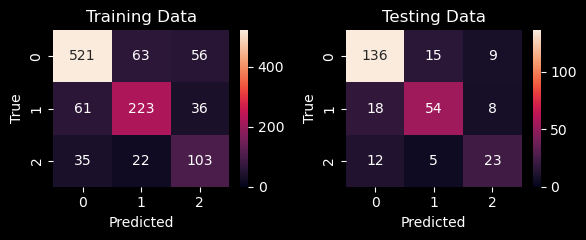

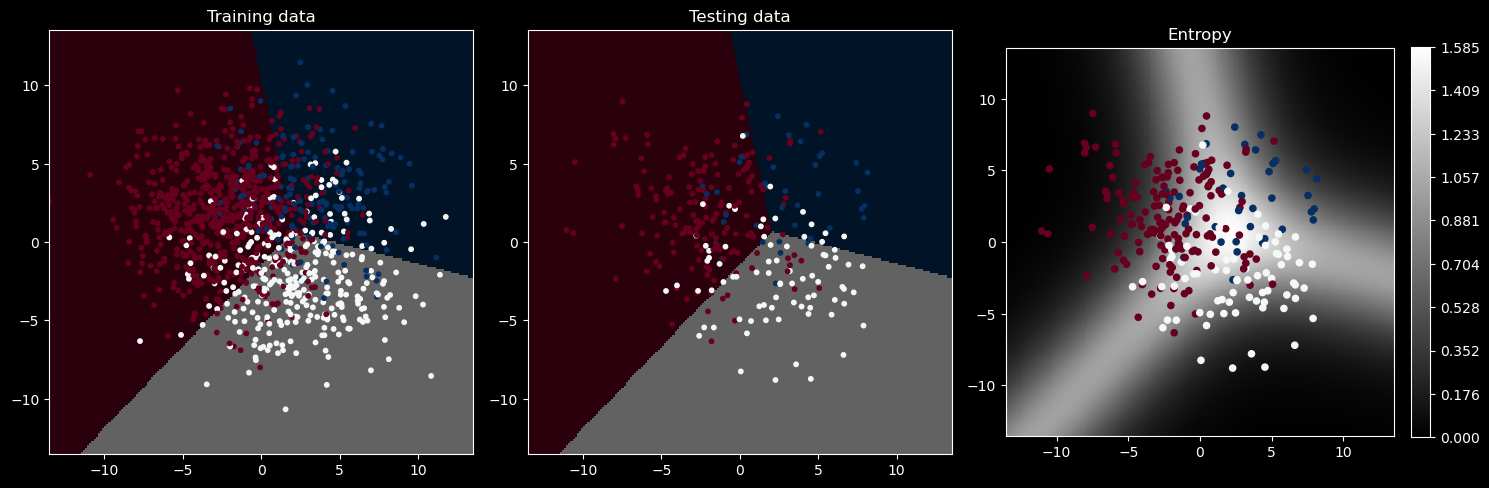

In [11]:
#########################
### CHECK PERFORMANCE ###
#########################
model = grid_search.best_estimator_

y_train_pred = model.predict(X_train).astype(int)
y_test_pred = model.predict(X_test).astype(int)

print(classification_report(y_test, y_test_pred))

conf_matrix_train = confusion_matrix(y_train, y_train_pred).astype(int)
conf_matrix_test = confusion_matrix(y_test, y_test_pred).astype(int)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2.5))

sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='d', ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Training Data")

sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='d', ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_title("Testing Data")

plt.tight_layout()
plt.show()

B, S = visualize_regions(model, MAX, 200)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,5))

extent = [-MAX,MAX,-MAX,MAX]

cmap = "RdBu"
axes[0].imshow(B, interpolation='none', extent=extent,cmap=cmap, alpha=0.4)
axes[0].scatter(X_train[:,0], X_train[:,1], c=y_train, s=10, cmap=cmap);
axes[0].set_aspect('equal')
axes[0].set_title('Training data');

axes[1].imshow(B, interpolation='none', extent=extent,cmap=cmap, alpha=0.4)
axes[1].scatter(X_test[:,0], X_test[:,1], c=y_test, s=10, cmap=cmap);
axes[1].set_aspect('equal')
axes[1].set_title('Testing data');

im = axes[2].imshow(S, interpolation='none', extent=extent,cmap='gray')
axes[2].scatter(X_test[:,0], X_test[:,1], c=y_test, s=20, cmap=cmap);
axes[2].set_aspect('equal')
axes[2].set_title('Entropy')
cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
cbar.set_ticks(np.linspace(0, math.log(y.max()+1,2), 10))

plt.tight_layout()
plt.show()

## 4. Review

- **Beyond two classes, weight tuning is a search over a simplex**, not a sweep along a line.
- **The Dirichlet distribution samples that simplex directly** — every draw is positive and sums to
  1. With all $\alpha_k = 1$ the draws are uniform over the space.
- **$\alpha < 1$ concentrates draws at the corners, $\alpha > 1$ at the centre**, which is a useful
  dial when the good weights are likely to be lopsided.
- **`GridSearchCV` accepts any candidate list**, so passing sampled weights turns it into a random
  search — and random search beats a grid in high dimensions, where most grid points are wasted.
- **Score with macro $F_1$ and stratified folds** so small classes carry equal weight in selection
  and appear in every fold.